<a href="https://colab.research.google.com/github/alx87grd/minilink/blob/dev-alex/examples/notebooks/demo_bicycle_trajopt_obstacle_scene_compare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Obstacle-scene TrajOpt — model complexity compare

This notebook mirrors [`demo_bicycle_trajopt_obstacle_scene_compare.py`](../scripts/trajectory_optimization/demo_bicycle_trajopt_obstacle_scene_compare.py): one short obstacle-avoidance mission, solved with **direct collocation** on six JAX plants ordered by state dimension (simplest → richest).

**The question:** for the *same* scene and soft costs, how do planned paths, speeds, and solve times change as the plant model grows from a holonomic point to a dynamic bicycle with rate inputs?

---

## The recipe at a glance

| Step | Ingredient (math) | Software helper |
| --- | --- | --- |
| 1 | Mission knobs: horizon, speed target, obstacle keepout | shared constants |
| 2 | Workspace obstacle (union SDF) | `Scene` + `Sphere` |
| 3 | Six plants $\dot{\mathbf{x}}=\mathbf{f}(\mathbf{x},\mathbf{u})$ + bounds / $Q,R,S$ | per-model builders |
| 4 | Soft tracking + soft clearance | `QuadraticCost` + `clearance_field(...).as_cost` |
| 5 | OCP → NLP → solve | `PlanningProblem` + `TrajectoryOptimizationPlanner` |
| 6 | Compare paths, speeds, timings | plots + summary table |
| 7 | Animate each plan (optional) | `sys.animate` |

Plants (by state dim $n$):

| $n$ | Plant | State gist | Inputs |
| --- | --- | --- | --- |
| 2 | `JaxHolonomicMobileRobot` | $[x,y]$ | $[v_x,v_y]$ |
| 3 | `JaxKinematicBicycle` | $[x,y,\theta]$ | $[v,\delta]$ |
| 4 | `JaxDynamicHolonomicMobileRobot` | $[x,y,v_x,v_y]$ | $[a_x,a_y]$ |
| 5 | `JaxKinematicBicycleRateInputs` | $[x,y,\theta,v,\delta]$ | $[\dot v,\dot\delta]$ |
| 6 | `JaxDynamicBicycle` | pose + body velocities | $[\omega_r,\delta]$ |
| 8 | `JaxDynamicBicycleRateInputs` | + actuator states | rate inputs |

Run from the minilink repository root with `pip install -e ".[jax]"` (or the `minilink` conda env).


In [1]:
# Local conda: minilink already installed. Colab: clone + path + meshcat.
import sys

if "google.colab" in sys.modules:
    get_ipython().run_line_magic("matplotlib", "inline")
    get_ipython().system("git clone -b dev-alex https://github.com/alx87grd/minilink")
    sys.path.insert(0, "/content/minilink")
    get_ipython().system("pip install -q meshcat")


Cloning into 'minilink'...
remote: Enumerating objects: 7120, done.
remote: Counting objects: 100% (883/883), done.
remote: Compressing objects: 100% (282/282), done.
remote: Total 7120 (delta 698), reused 646 (delta 601), pack-reused 6237 (from 1)
Receiving objects: 100% (7120/7120), 142.95 MiB | 13.81 MiB/s, done.
Resolving deltas: 100% (4957/4957), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 101.1 MB/s eta 0:00:00


In [2]:
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np

from minilink.core.backends import configure_jax
from minilink.core.costs import QuadraticCost
from minilink.core.geometry import Sphere
from minilink.core.trajectory import Trajectory
from minilink.dynamics.catalog.vehicles.dynamic_bicycle import (
    JaxDynamicBicycle,
    JaxDynamicBicycleRateInputs,
)
from minilink.dynamics.catalog.vehicles.steering import (
    JaxDynamicHolonomicMobileRobot,
    JaxHolonomicMobileRobot,
    JaxKinematicBicycle,
    JaxKinematicBicycleRateInputs,
)
from minilink.planning.problems import PlanningProblem
from minilink.planning.spatial.collision import bind, point_probe
from minilink.planning.spatial.scene import Scene
from minilink.planning.spatial.shaping import inverse_barrier
from minilink.planning.trajectory_optimization.direct_collocation import (
    DirectCollocationOptions,
    DirectCollocationTranscription,
)
from minilink.planning.trajectory_optimization.planner import (
    TrajectoryOptimizationOptions,
    TrajectoryOptimizationPlanner,
)

configure_jax(enable_x64=True)


<module 'jax' from '/usr/local/lib/python3.12/dist-packages/jax/__init__.py'>

## 1. Mission parameters

Fixed horizon $t_f$ and collocation grid. Soft goal: reach world-$x \approx u_\mathrm{target}\, t_f$ while staying near $y=0$, dodging one sphere keepout. Bounds below are shared mission knobs; each plant maps them onto its own ports and state indices.


In [3]:
TF = 4.0
N_STEPS = 20
U_0 = 8.0
U_TARGET = 10.0
Y_START = 0.0
Y_GOAL = 0.0
HEADING_TARGET = 0.0
DELTA_MAX = 0.25
V_MAX = 20.0
SPEED_DOT_MAX = 3.0
STEERING_DOT_MAX = 2.0
W_REAR_DOT_MAX = 80.0
DELTA_DOT_MAX = 2.0

OBSTACLE_CENTER = (12.0, 0.2)
OBSTACLE_RADIUS = 0.4
OBSTACLE_MARGIN = 0.2
OBSTACLE_REPULSION_WEIGHT = 1000.0
OBSTACLE_REPULSION_EPS = 1.0
PLOT_BOUNDS = ((-2.0, U_TARGET * TF + 2.0), (-3.5, 2.0))

PATH_COLORS = (
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
)


def terminal_x() -> float:
    return U_TARGET * TF


print(f"horizon tf={TF}s, grid steps={N_STEPS}, soft goal x≈{terminal_x():.1f} m")


horizon tf=4.0s, grid steps=20, soft goal x≈40.0 m


## 2. Workspace scene

A single sphere with radius = geometric radius + planning margin. Soft clearance later uses `inverse_barrier` on the signed clearance field — there is **no** hard collision constraint in this demo.


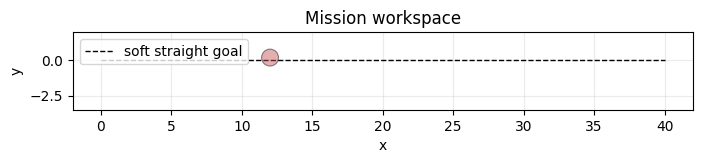

In [4]:
keepout_radius = OBSTACLE_RADIUS + OBSTACLE_MARGIN
scene = Scene(obstacles=[Sphere(OBSTACLE_CENTER, keepout_radius)])
overlay = scene.as_visualizer(color="tab:red", opacity=0.45)

fig, ax = plt.subplots(figsize=(8.0, 3.5))
scene.plot(show=False, ax=ax, bounds=PLOT_BOUNDS, show_density=False, title="Mission workspace")
ax.plot([0.0, terminal_x()], [Y_START, Y_GOAL], "k--", linewidth=1.0, label="soft straight goal")
ax.legend(loc="upper left")
plt.show()


## 3. Per-model builders

Each builder returns the plant plus TrajOpt ingredients sized to that plant:

- `x_start` — initial state
- `x_ref`, `ubar` — quadratic tracking / terminal references
- `Q`, `R`, `S` — running state, input, and terminal weights

Common theme across models: **no running weight on world-$x$** (`Q_{00}=0`); progress comes from the fixed horizon and terminal $S$. Y-tracking is emphasized so every plant must weave around the obstacle rather than cutting $y=0$ through the keepout.

Point models have no heading; bicycles carry $\theta$ (and often speed / steering) in the cost.


In [5]:
@dataclass(frozen=True)
class ModelCase:
    key: str
    title: str
    color: str


@dataclass
class SolveRun:
    case: ModelCase
    sys: object
    traj: Trajectory
    success: bool
    cost: float | None
    solve_s: float | None
    total_s: float


MODEL_CASES = (
    ModelCase("holonomic", "Holonomic", PATH_COLORS[0]),
    ModelCase("kinematic", "Kinematic", PATH_COLORS[1]),
    ModelCase("holonomic_dyn", "Holonomic dyn", PATH_COLORS[2]),
    ModelCase("kinematic_rate", "Kinematic rate", PATH_COLORS[3]),
    ModelCase("dynamic", "Dynamic", PATH_COLORS[4]),
    ModelCase("dynamic_rate", "Dynamic rate", PATH_COLORS[5]),
)


def build_holonomic():
    sys = JaxHolonomicMobileRobot()
    sys.inputs["u"].lower_bound = np.array([0.0, -V_MAX])
    sys.inputs["u"].upper_bound = np.array([V_MAX, V_MAX])
    x_start = np.array([0.0, Y_START])
    x_ref = np.array([terminal_x(), Y_GOAL])
    ubar = np.array([U_TARGET, 0.0])
    Q = np.diag([0.0, 10.0])
    R = np.diag([0.5, 0.5])
    S = np.diag([1.0, 10.0])
    return sys, x_start, x_ref, ubar, Q, R, S


def build_holonomic_dyn():
    sys = JaxDynamicHolonomicMobileRobot()
    sys.state.lower_bound[2] = 0.0
    sys.state.upper_bound[2] = V_MAX
    sys.state.lower_bound[3] = -V_MAX
    sys.state.upper_bound[3] = V_MAX
    sys.inputs["u"].lower_bound = np.array([-SPEED_DOT_MAX, -SPEED_DOT_MAX])
    sys.inputs["u"].upper_bound = np.array([SPEED_DOT_MAX, SPEED_DOT_MAX])
    x_start = np.array([0.0, Y_START, U_0, 0.0])
    x_ref = np.array([terminal_x(), Y_GOAL, U_TARGET, 0.0])
    ubar = np.array([0.0, 0.0])
    Q = np.diag([0.0, 10.0, 0.1, 0.1])
    R = np.diag([1.0, 1.0])
    S = np.diag([1.0, 10.0, 10.0, 1.0])
    return sys, x_start, x_ref, ubar, Q, R, S


def build_kinematic():
    sys = JaxKinematicBicycle()
    sys.inputs["u"].lower_bound = np.array([0.0, -DELTA_MAX])
    sys.inputs["u"].upper_bound = np.array([V_MAX, DELTA_MAX])
    x_start = np.array([0.0, Y_START, 0.0])
    x_ref = np.array([terminal_x(), Y_GOAL, HEADING_TARGET])
    ubar = np.array([U_TARGET, 0.0])
    Q = np.diag([0.0, 10.0, 1.0])
    R = np.diag([0.5, 10.0])
    S = np.diag([1.0, 10.0, 100.0])
    return sys, x_start, x_ref, ubar, Q, R, S


def build_kinematic_rate():
    sys = JaxKinematicBicycleRateInputs()
    sys.state.lower_bound[3] = 0.0
    sys.state.upper_bound[3] = V_MAX
    sys.state.lower_bound[4] = -DELTA_MAX
    sys.state.upper_bound[4] = DELTA_MAX
    sys.inputs["speed_dot"].lower_bound[0] = -SPEED_DOT_MAX
    sys.inputs["speed_dot"].upper_bound[0] = SPEED_DOT_MAX
    sys.inputs["steering_dot"].lower_bound[0] = -STEERING_DOT_MAX
    sys.inputs["steering_dot"].upper_bound[0] = STEERING_DOT_MAX
    x_start = np.array([0.0, Y_START, 0.0, U_0, 0.0])
    x_ref = np.array([terminal_x(), Y_GOAL, HEADING_TARGET, U_TARGET, 0.0])
    ubar = np.array([0.0, 0.0])
    Q = np.diag([0.0, 10.0, 1.0, 0.1, 100.0])
    R = np.diag([1.0, 10.0])
    S = np.diag([1.0, 10.0, 100.0, 10.0, 100.0])
    return sys, x_start, x_ref, ubar, Q, R, S


def build_dynamic():
    sys = JaxDynamicBicycle()
    r_r = sys.params["r_r"]
    w_rear_max = 1.2 * U_TARGET / r_r
    sys.inputs["w_rear"].lower_bound[0] = 0.0
    sys.inputs["w_rear"].upper_bound[0] = w_rear_max
    sys.inputs["delta"].lower_bound[0] = -DELTA_MAX
    sys.inputs["delta"].upper_bound[0] = DELTA_MAX
    x_start = np.array([0.0, Y_START, 0.0, U_0, 0.0, 0.0])
    x_ref = np.array([terminal_x(), Y_GOAL, HEADING_TARGET, U_TARGET, 0.0, 0.0])
    ubar = np.array([U_TARGET / r_r, 0.0])
    Q = np.diag([0.0, 10.0, 1.0, 0.1, 0.1, 0.1])
    R = np.diag([0.5, 10.0])
    S = np.diag([1.0, 10.0, 100.0, 10.0, 0.0, 0.1])
    return sys, x_start, x_ref, ubar, Q, R, S


def build_dynamic_rate():
    sys = JaxDynamicBicycleRateInputs()
    r_r = sys.params["r_r"]
    w_rear_max = 1.2 * U_TARGET / r_r
    sys.state.lower_bound[6] = 0.0
    sys.state.upper_bound[6] = w_rear_max
    sys.state.lower_bound[7] = -DELTA_MAX
    sys.state.upper_bound[7] = DELTA_MAX
    sys.inputs["w_rear_dot"].lower_bound[0] = -W_REAR_DOT_MAX
    sys.inputs["w_rear_dot"].upper_bound[0] = W_REAR_DOT_MAX
    sys.inputs["delta_dot"].lower_bound[0] = -DELTA_DOT_MAX
    sys.inputs["delta_dot"].upper_bound[0] = DELTA_DOT_MAX
    x_start = np.array([0.0, Y_START, 0.0, U_0, 0.0, 0.0, U_0 / r_r, 0.0])
    x_ref = np.array(
        [terminal_x(), Y_GOAL, HEADING_TARGET, U_TARGET, 0.0, 0.0, U_TARGET / r_r, 0.0]
    )
    ubar = np.array([0.0, 0.0])
    Q = np.diag([0.0, 10.0, 1.0, 0.1, 0.1, 0.1, 0.1, 100.0])
    R = np.diag([1.0, 10.0])
    S = np.diag([1.0, 10.0, 100.0, 10.0, 0.0, 0.1, 0.1, 100.0])
    return sys, x_start, x_ref, ubar, Q, R, S


BUILDERS = {
    "holonomic": build_holonomic,
    "holonomic_dyn": build_holonomic_dyn,
    "kinematic": build_kinematic,
    "kinematic_rate": build_kinematic_rate,
    "dynamic": build_dynamic,
    "dynamic_rate": build_dynamic_rate,
}

for case in MODEL_CASES:
    sys, x_start, *_ = BUILDERS[case.key]()
    print(f"{case.title:<16} n={sys.n}  m={sys.m}  x0={np.array2string(x_start, precision=2)}")


Holonomic        n=2  m=2  x0=[0. 0.]
Kinematic        n=3  m=2  x0=[0. 0. 0.]
Holonomic dyn    n=4  m=2  x0=[0. 0. 8. 0.]
Kinematic rate   n=5  m=2  x0=[0. 0. 0. 8. 0.]
Dynamic          n=6  m=2  x0=[0. 0. 0. 8. 0. 0.]
Dynamic rate     n=8  m=2  x0=[ 0.    0.    0.    8.    0.    0.   26.67  0.  ]


## 4–5. Cost, transcription, and solve

For each plant:

1. **Tracking cost** — quadratic state/input penalties about $(x_\mathrm{ref}, \bar u)$.
2. **Obstacle cost** — bind a point probe on the plant body frame to the scene clearance field, then shape with an inverse barrier (large near contact, soft far away).
3. **Planning problem** — plant + start + summed cost (bounds come from the plant ports / state boxes).
4. **Direct collocation** — fixed grid (`tf`, `n_steps`), JAX-compiled NLP, SLSQP-style solve.

First-time JAX compiles dominate wall-clock `total_s`; compare `solve_s` for NLP-only timing when available.


In [6]:
def speed_profile(case: ModelCase, traj: Trajectory) -> np.ndarray:
    if case.key == "holonomic":
        return np.hypot(traj.u[0, :], traj.u[1, :])
    if case.key == "holonomic_dyn":
        return np.hypot(traj.x[2, :], traj.x[3, :])
    if case.key == "kinematic":
        return traj.u[0, :]
    if case.key == "kinematic_rate":
        return traj.x[3, :]
    return np.hypot(traj.x[3, :], traj.x[4, :])


def solve_case(case: ModelCase, scene: Scene) -> SolveRun:
    sys, x_start, x_ref, ubar, Q, R, S = BUILDERS[case.key]()
    tracking_cost = QuadraticCost.from_system(
        sys, Q=Q, R=R, S=S, xbar=x_ref, ubar=ubar
    )
    obstacle_cost = scene.clearance_field(bind(sys, point_probe())).as_cost(
        weight=OBSTACLE_REPULSION_WEIGHT,
        shaping=inverse_barrier(epsilon=OBSTACLE_REPULSION_EPS),
    )
    problem = PlanningProblem(
        sys=sys, x_start=x_start, cost=tracking_cost + obstacle_cost
    )
    planner = TrajectoryOptimizationPlanner(
        problem,
        transcription=DirectCollocationTranscription(
            DirectCollocationOptions(tf=TF, n_steps=N_STEPS)
        ),
        options=TrajectoryOptimizationOptions(
            compile_backend="jax",
            record_solve_time=True,
            optimizer_options={"maxiter": 500, "ftol": 1e-1},
        ),
    )

    t0 = time.perf_counter()
    traj = planner.compute_solution()
    total_s = time.perf_counter() - t0
    result = planner.last_optimization_result
    return SolveRun(
        case=case,
        sys=sys,
        traj=traj,
        success=bool(result.success),
        cost=None if result.cost is None else float(result.cost),
        solve_s=None if result.solve_time_s is None else float(result.solve_time_s),
        total_s=total_s,
    )


runs = [solve_case(case, scene) for case in MODEL_CASES]
print(f"solved {len(runs)} models")


solved 6 models


## 6. Compare results

Summary table, then a $2\times 3$ path panel and an overlay of all XY paths plus reconstructed speed profiles. Speed extraction differs by plant (input for kinematic / holonomic; state for rate / dynamic models).


In [7]:
print("TrajOpt obstacle scene — model comparison")
print(f"  tf={TF}s, n_steps={N_STEPS}, u_target={U_TARGET} m/s")
print(f"  obstacle={OBSTACLE_CENTER}, keepout R={keepout_radius}")
print(f"{'model':<18} {'success':>8} {'solve_s':>9} {'total_s':>9} {'J*':>12} {'x_f':>8}")
for run in runs:
    solve_s = "—" if run.solve_s is None else f"{run.solve_s:.3f}"
    cost = "—" if run.cost is None else f"{run.cost:.1f}"
    print(
        f"{run.case.title:<18} {str(run.success):>8} {solve_s:>9} "
        f"{run.total_s:>9.3f} {cost:>12} {run.traj.x[0, -1]:>8.1f}"
    )


TrajOpt obstacle scene — model comparison
  tf=4.0s, n_steps=20, u_target=10.0 m/s
  obstacle=(12.0, 0.2), keepout R=0.6000000000000001
model               success   solve_s   total_s           J*      x_f
Holonomic              True     0.447     5.737        192.8     39.6
Kinematic              True     0.252     3.719        172.5     40.0
Holonomic dyn          True     0.144     1.299        300.7     39.9
Kinematic rate         True     0.199     1.467        216.2     40.9
Dynamic                True     2.349     6.493        500.8     35.9
Dynamic rate           True     0.336     4.562        285.4     37.5


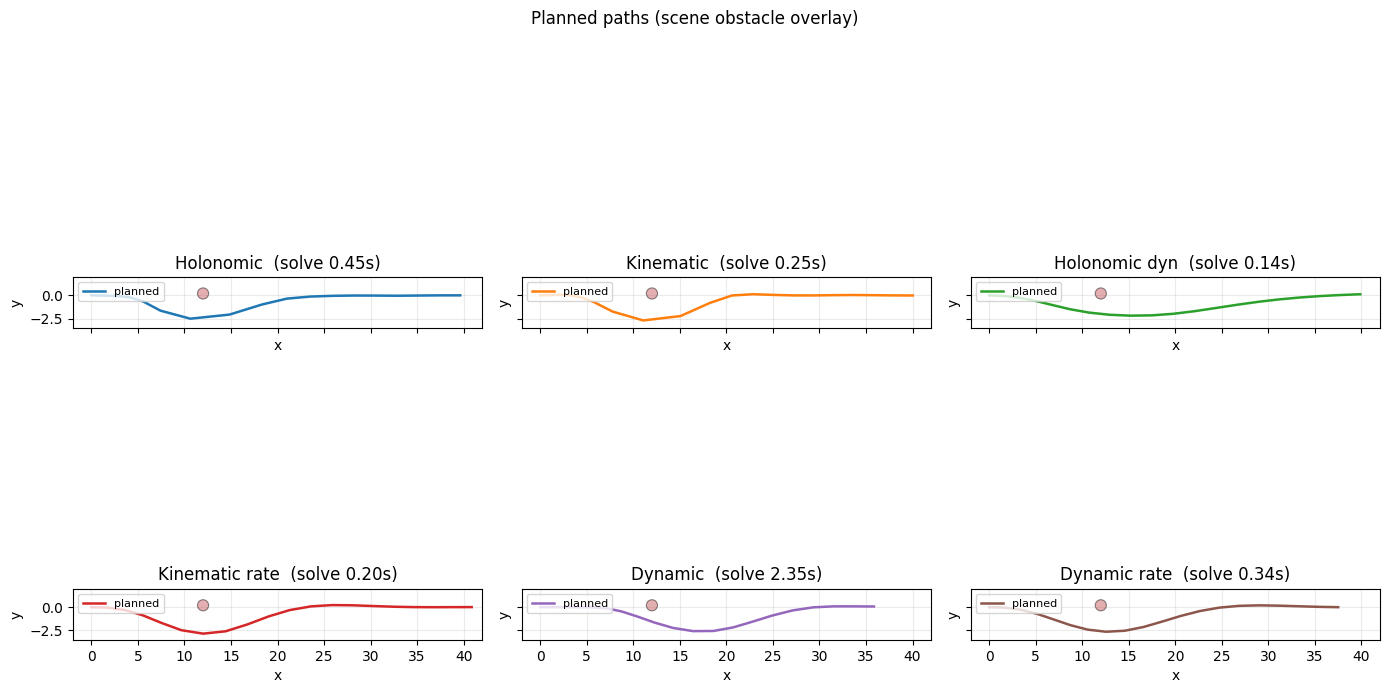

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14.0, 9.0), sharex=True, sharey=True)
for ax, run in zip(axes.ravel(), runs, strict=True):
    scene.plot(show=False, ax=ax, bounds=PLOT_BOUNDS, show_density=False, title="")
    ax.plot(
        run.traj.x[0, :],
        run.traj.x[1, :],
        color=run.case.color,
        linewidth=1.8,
        label="planned",
    )
    solve_s = "—" if run.solve_s is None else f"{run.solve_s:.2f}s"
    ax.set_title(f"{run.case.title}  (solve {solve_s})")
    ax.legend(loc="upper left", fontsize=8)
fig.suptitle("Planned paths (scene obstacle overlay)")
fig.tight_layout()
plt.show()


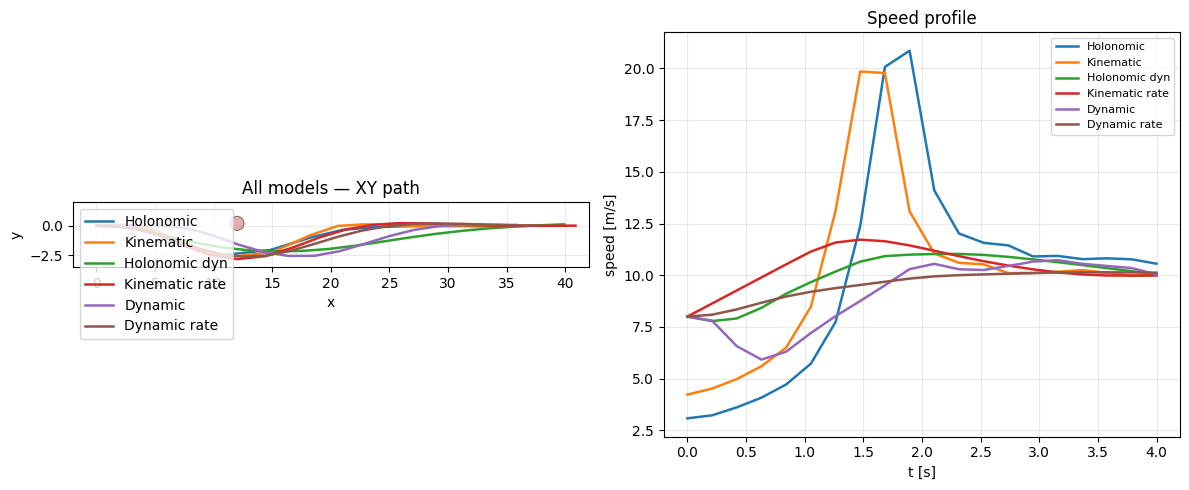

In [9]:
fig, (ax_path, ax_speed) = plt.subplots(1, 2, figsize=(12.0, 5.0))

scene.plot(show=False, ax=ax_path, bounds=PLOT_BOUNDS, show_density=False, title="")
for run in runs:
    ax_path.plot(
        run.traj.x[0, :],
        run.traj.x[1, :],
        color=run.case.color,
        linewidth=1.8,
        label=run.case.title,
    )
ax_path.set_title("All models — XY path")
ax_path.legend(loc="upper left")

for run in runs:
    ax_speed.plot(
        run.traj.t,
        speed_profile(run.case, run.traj),
        color=run.case.color,
        linewidth=1.8,
        label=run.case.title,
    )
ax_speed.set_xlabel("t [s]")
ax_speed.set_ylabel("speed [m/s]")
ax_speed.set_title("Speed profile")
ax_speed.grid(True, alpha=0.25)
ax_speed.legend(loc="best", fontsize=8)

fig.tight_layout()
plt.show()


## 7. Animate (optional)

Each plant keeps its own skin (circle for holonomic points, car for bicycles). Set `ANIMATE = True` to play all six with the same obstacle overlay. Skip in headless runs.


In [10]:
ANIMATE = False  # set True to play interactive animations

if ANIMATE:
    for run in runs:
        print(f"Animating {run.case.title}...")
        run.sys.traj = run.traj
        run.sys.animate(run.traj, overlays=[overlay], renderer="meshcat", html=False, native=False)
else:
    print("Skipped animations (set ANIMATE = True to play).")


Skipped animations (set ANIMATE = True to play).
